In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import classification_report, accuracy_score


In [3]:
df = pd.read_csv("/content/bank.csv", sep=None, engine="python")

print("Shape:", df.shape)
df.head()


Shape: (11162, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [4]:
for col in df.select_dtypes(include=["object"]).columns:
    df[col] = df[col].astype(str).str.strip().str.lower()

print(df["deposit"].value_counts())


deposit
no     5873
yes    5289
Name: count, dtype: int64


In [5]:
X = df.drop("deposit", axis=1)
y = df["deposit"].map({"no": 0, "yes": 1}).astype(int)

print("Target distribution:\n", y.value_counts())


Target distribution:
 deposit
0    5873
1    5289
Name: count, dtype: int64


In [6]:
num_cols = X.select_dtypes(include=["int64","float64"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()

print("Numeric columns:", num_cols)
print("Categorical columns:", cat_cols)


Numeric columns: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
Categorical columns: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


In [7]:
numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer([
    ("num", numeric_pipe, num_cols),
    ("cat", cat_pipe, cat_cols)
])


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [9]:
X_train_t = preprocess.fit_transform(X_train)
X_test_t  = preprocess.transform(X_test)

tree = DecisionTreeClassifier(max_depth=4, random_state=42, criterion="gini")
tree.fit(X_train_t, y_train)


DecisionTreeClassifier(max_depth=4, random_state=42)

In [10]:
train_pred = tree.predict(X_train_t)
test_pred  = tree.predict(X_test_t)

train_acc = accuracy_score(y_train, train_pred)
test_acc  = accuracy_score(y_test, test_pred)

print("Train Accuracy:", train_acc)
print("Test Accuracy :", test_acc)


Train Accuracy: 0.7804905364542502
Test Accuracy : 0.781012091356919


In [11]:
print(classification_report(y_test, test_pred))


              precision    recall  f1-score   support

           0       0.85      0.71      0.77      1175
           1       0.73      0.86      0.79      1058

    accuracy                           0.78      2233
   macro avg       0.79      0.78      0.78      2233
weighted avg       0.79      0.78      0.78      2233



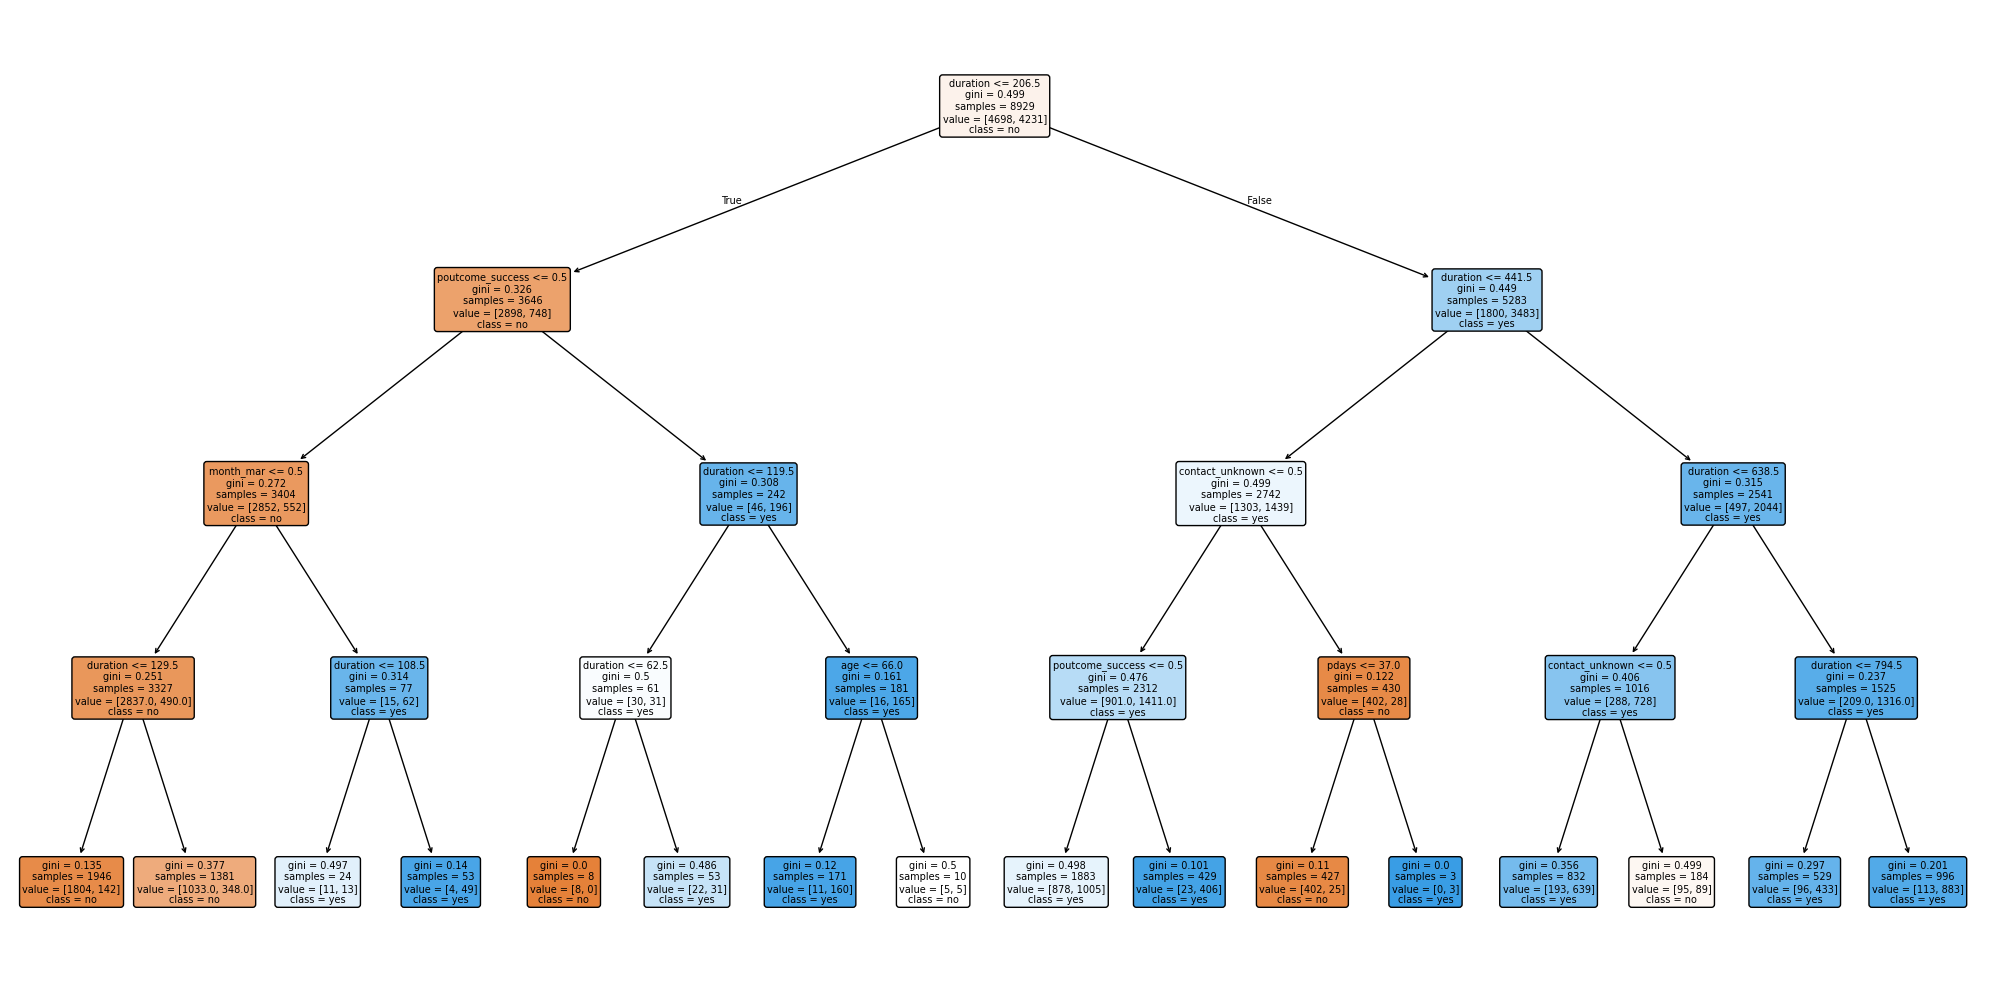

✅ Saved: decision_tree.png


In [12]:
ohe = preprocess.named_transformers_["cat"].named_steps["onehot"]
cat_feature_names = ohe.get_feature_names_out(cat_cols).tolist()
feature_names = num_cols + cat_feature_names

plt.figure(figsize=(20,10))
plot_tree(
    tree,
    feature_names=feature_names,
    class_names=["no", "yes"],
    filled=True,
    rounded=True,
    fontsize=7
)

plt.tight_layout()
plt.savefig("decision_tree.png", dpi=150)
plt.show()

print("✅ Saved: decision_tree.png")


In [13]:
report_path = "bank_tree_evaluation_report.txt"

with open(report_path, "w") as f:
    f.write("Bank Marketing Subscription Prediction - Decision Tree\n")
    f.write("=====================================================\n\n")
    f.write(f"Train Accuracy: {train_acc:.4f}\n")
    f.write(f"Test Accuracy : {test_acc:.4f}\n\n")
    f.write("Classification Report (Test):\n")
    f.write(classification_report(y_test, test_pred))

print("✅ Saved:", report_path)


✅ Saved: bank_tree_evaluation_report.txt


In [14]:
rules = export_text(tree, feature_names=feature_names, max_depth=3)
print(rules)


|--- duration <= 206.50
|   |--- poutcome_success <= 0.50
|   |   |--- month_mar <= 0.50
|   |   |   |--- duration <= 129.50
|   |   |   |   |--- class: 0
|   |   |   |--- duration >  129.50
|   |   |   |   |--- class: 0
|   |   |--- month_mar >  0.50
|   |   |   |--- duration <= 108.50
|   |   |   |   |--- class: 1
|   |   |   |--- duration >  108.50
|   |   |   |   |--- class: 1
|   |--- poutcome_success >  0.50
|   |   |--- duration <= 119.50
|   |   |   |--- duration <= 62.50
|   |   |   |   |--- class: 0
|   |   |   |--- duration >  62.50
|   |   |   |   |--- class: 1
|   |   |--- duration >  119.50
|   |   |   |--- age <= 66.00
|   |   |   |   |--- class: 1
|   |   |   |--- age >  66.00
|   |   |   |   |--- class: 0
|--- duration >  206.50
|   |--- duration <= 441.50
|   |   |--- contact_unknown <= 0.50
|   |   |   |--- poutcome_success <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- poutcome_success >  0.50
|   |   |   |   |--- class: 1
|   |   |--- contact_unknown >  0.5